<a href="https://colab.research.google.com/github/elig18/Study-case-MNIST/blob/main/Studycase_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Etude de cas** : MNIST
- Le but principal du projet est de concevoir un modèle de Deep Learning de classification
d’images selon 10 catégories.

Module : Fondements des réseaux de neurones convolutifs

Rendu 29 mars 2026

Elisabeth GIL

B3 IA - Nexa Digital School

In [ ]:
# Import des librairies nécessaires et dataset
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
from google.colab import files
import cv2

## **I. Présenter dataset imposé**

In [ ]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
#2.
print("Exploration des données:")


print(f" Données: {X_train.shape}")
print(f"   = {X_train.shape[0]} images de taille {X_train.shape[1]}×{X_train.shape[2]} pixels")
print(f"\n Labels d'entraînement : {Y_train.shape}")
print(f"   = {Y_train.shape[0]} étiquettes (chiffres de 0 à 9)")

print(f"\n Données de test : {X_test.shape}")
print(f"   = {X_test.shape[0]} images de taille {X_test.shape[1]}×{X_test.shape[2]} pixels")
print(f"\n  Labels de test : {Y_test.shape}")
print(f"   = {Y_test.shape[0]} étiquettes")

print(f"\n Niveau de gris : de {X_train.min()} (noir) à {X_train.max()} (blanc)")


Exploration des données:
 Données: (60000, 28, 28)
   = 60000 images de taille 28×28 pixels

 Labels d'entraînement : (60000,)
   = 60000 étiquettes (chiffres de 0 à 9)

 Données de test : (10000, 28, 28)
   = 10000 images de taille 28×28 pixels

  Labels de test : (10000,)
   = 10000 étiquettes

 Niveau de gris : de 0 (noir) à 255 (blanc)


Le dataset MNIST(Modified National Institute of Standards and Technology) est une base de données de chiffres manuscrits largement utilisée dans le Machine Learning.

Il y a :
- 60 000 images d'entraînement
- 10 000 images de test
- Format : Images en niveaux de gris de taille 28×28 pixels
- Classes : 10 classes (chiffres de 0 à 9)



In [ ]:
#3.
print("Distribution des classes")

unique, counts = np.unique(Y_train, return_counts=True)
print("\n Nombre d'exemples par chiffre (entraînement) :")
for digit, count in zip(unique, counts):
    print(f"   Chiffre {digit} : {count:5d} exemples ({count/len(Y_train)*100:.1f}%)")


Distribution des classes

 Nombre d'exemples par chiffre (entraînement) :
   Chiffre 0 :  5923 exemples (9.9%)
   Chiffre 1 :  6742 exemples (11.2%)
   Chiffre 2 :  5958 exemples (9.9%)
   Chiffre 3 :  6131 exemples (10.2%)
   Chiffre 4 :  5842 exemples (9.7%)
   Chiffre 5 :  5421 exemples (9.0%)
   Chiffre 6 :  5918 exemples (9.9%)
   Chiffre 7 :  6265 exemples (10.4%)
   Chiffre 8 :  5851 exemples (9.8%)
   Chiffre 9 :  5949 exemples (9.9%)


MNIST est utilisé pour l'apprentissage : tester et comprendre les algorithmes de classification par exemple.

VISUALISATION D'EXEMPLES


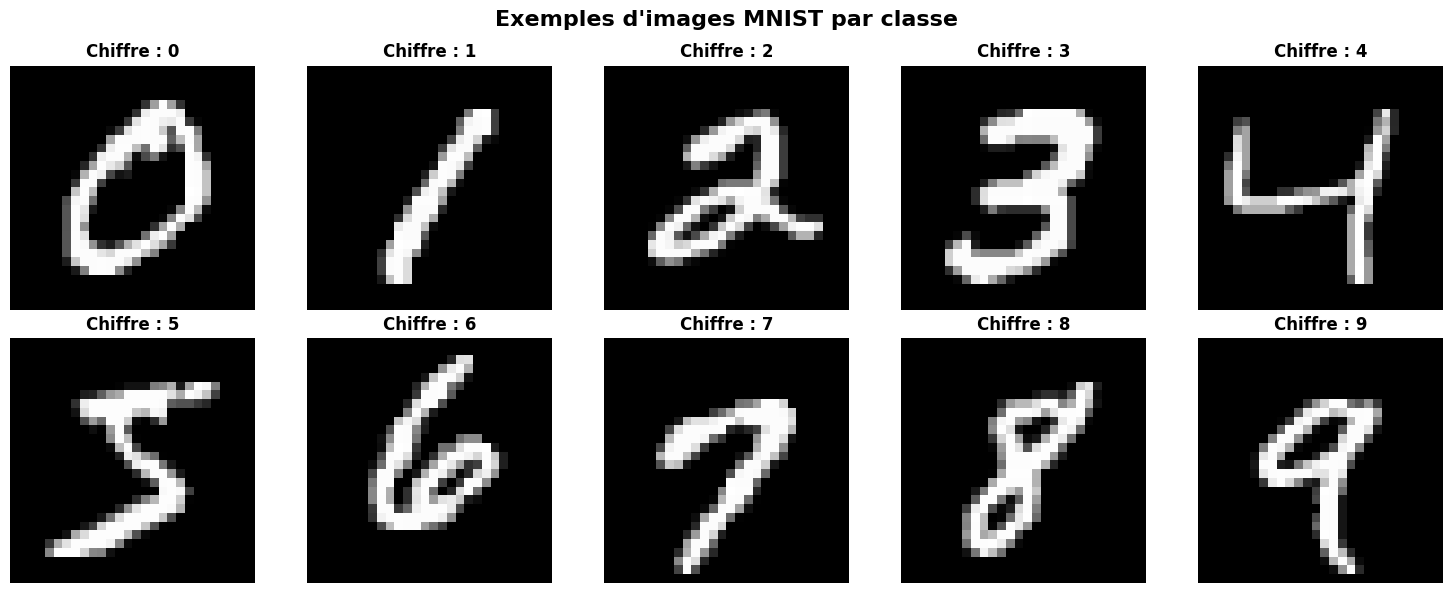

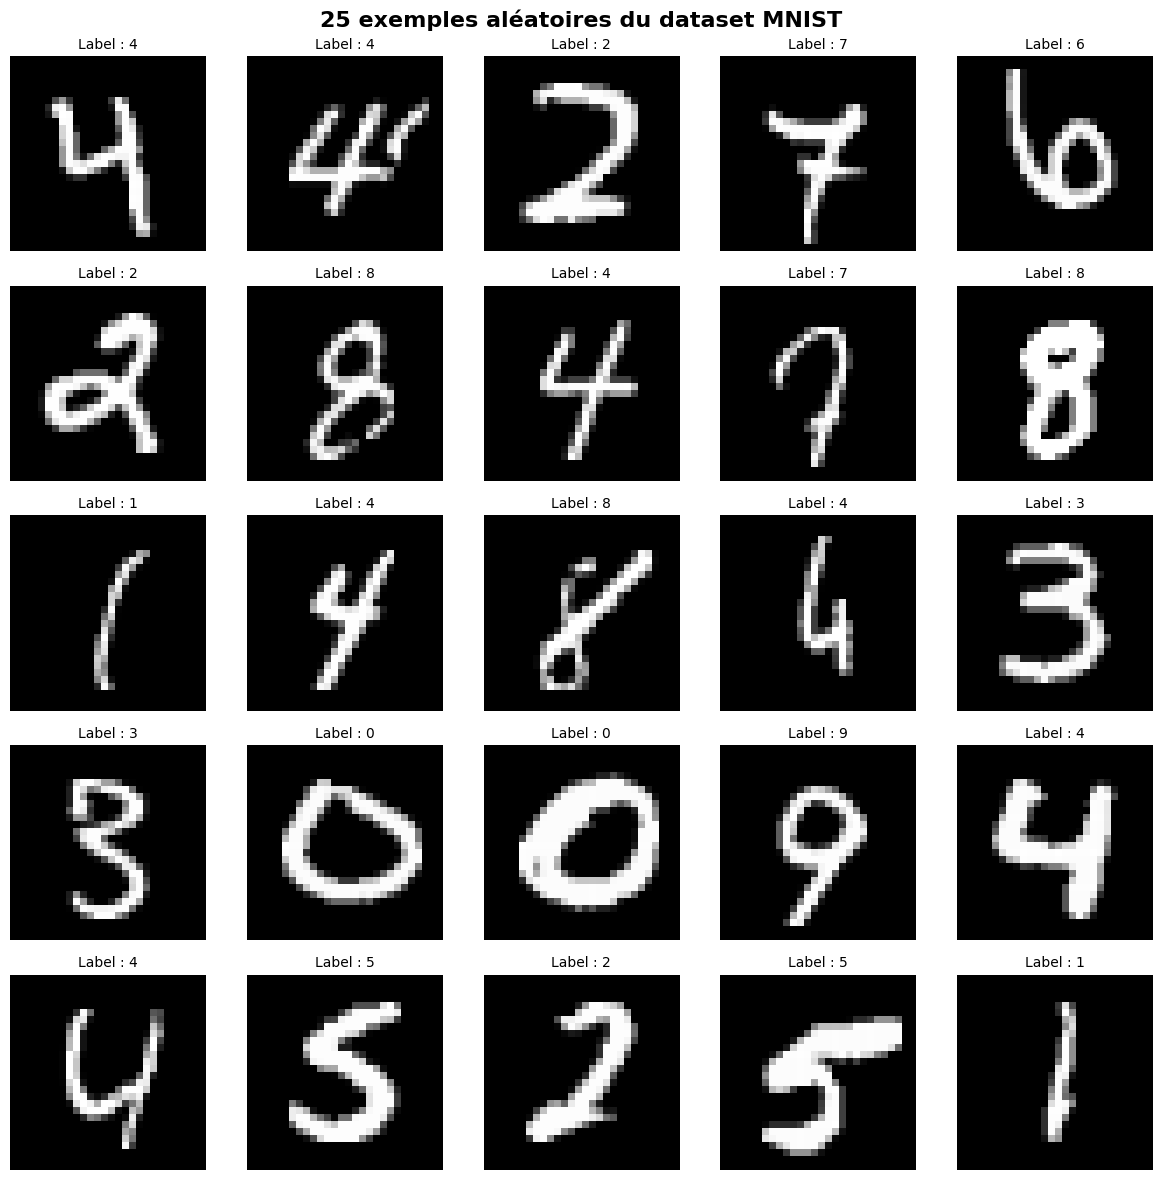

ANALYSE DÉTAILLÉE D'UNE IMAGE

 Image n°0
   Label : 5
   Shape : (28, 28)
   Min pixel value : 0
   Max pixel value : 255
   Mean pixel value : 35.11


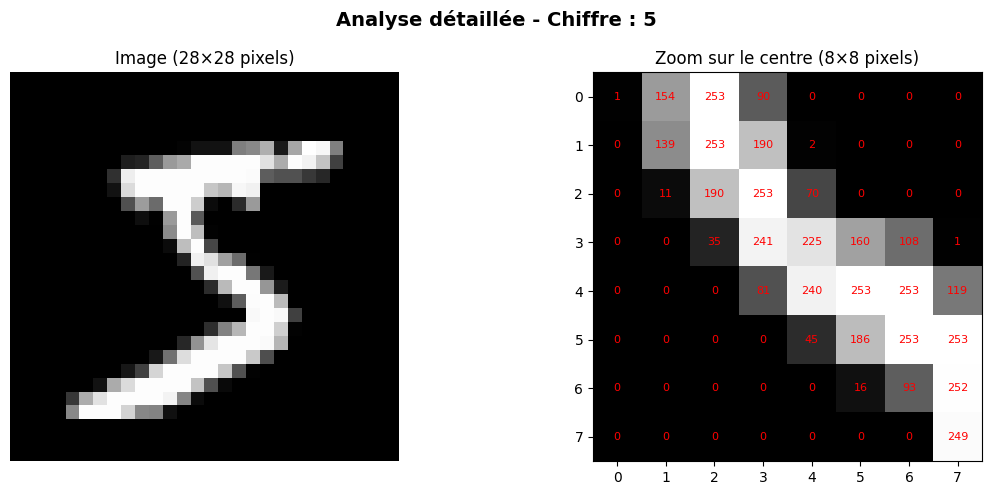

In [ ]:
#4.
print("VISUALISATION D'EXEMPLES")

plt.figure(figsize=(15, 6))
plt.suptitle("Exemples d'images MNIST par classe", fontsize=16, fontweight='bold')

for i in range(10):
    #Trouver le premier exemple de chaque chiffre
    idx = np.where(Y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Chiffre : {i}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

# 25 EXEMPLES ALÉATOIRES
plt.figure(figsize=(12, 12))
plt.suptitle("25 exemples aléatoires du dataset MNIST", fontsize=16, fontweight='bold')

indices = np.random.randint(0, len(X_train), 25)

for i, idx in enumerate(indices):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label : {Y_train[idx]}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

#ANALYSE D'UNE IMAGE INDIVIDUELLE
print("ANALYSE DÉTAILLÉE D'UNE IMAGE")

sample_idx = 0
sample_image = X_train[sample_idx]
sample_label = Y_train[sample_idx]

print(f"\n Image n°{sample_idx}")
print(f"   Label : {sample_label}")
print(f"   Shape : {sample_image.shape}")
print(f"   Min pixel value : {sample_image.min()}")
print(f"   Max pixel value : {sample_image.max()}")
print(f"   Mean pixel value : {sample_image.mean():.2f}")

# Affichage de l'image avec sa matrice de pixels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Analyse détaillée - Chiffre : {sample_label}", fontsize=14, fontweight='bold')

#Image
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title("Image (28×28 pixels)", fontsize=12)
axes[0].axis('off')

# Matrice de valeurs
axes[1].imshow(sample_image[10:18, 10:18], cmap='gray', interpolation='nearest')
axes[1].set_title("Zoom sur le centre (8×8 pixels)", fontsize=12)
for i in range(8):
    for j in range(8):
        text = axes[1].text(j, i, int(sample_image[10+i, 10+j]),
                           ha="center", va="center", color="red", fontsize=8)
axes[1].set_xticks(range(8))
axes[1].set_yticks(range(8))

plt.tight_layout()
plt.show()

Une fois entraîné sur MNIST, un modèle peut être appliqué par exemple à :
- Tri automatique du courrier : Lecture des codes postaux manuscrits
- Reconnaissance de chèques : Lecture des montants écrits à la main
- Analyse de sondages papier : Dépouillement automatique de questionnaires

Les techniques apprises sur MNIST peuvent être étendues à :
- Reconnaissance de lettres (alphabets)
- Classification de symboles mathématiques
- Détection de signatures


## **Partie II : Concevoir un modèle : réseaux neuronal classique avec des couches complètement connectés**

Nous avons conçu un réseau de neurones entièrement connecté (Fully Connected Network) composé de 5 couches

On a fait une architecture pyramidale (256 → 128 → 64) car elle suit une réduction progressive du nombre de neurones :
- La première couche dense (256) dispose d'un grand nombre de neurones pour capturer la richesse des informations brutes provenant des 784 pixels d'entrée.
- Les couches intermédiaires (128, 64)*effectuent une compression progressive, forçant le réseau à extraire les caractéristiques les plus discriminantes.
- Cette approche imite le fonctionnement du système visuel humain qui passe d'une représentation détaillée à une représentation abstraite.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Architecture du modèle :


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)


JUSTIFICATION DE L'ARCHITECTURE :
   - Flatten : Convertit l'image 28×28 en vecteur 784
   - Dense(256) : Première couche avec beaucoup de neurones pour extraire des features
   - Dropout(0.3) : Régularisation pour éviter le surapprentissage
   - Dense(128) → Dense(64) : Réduction progressive pour affiner les features
   - Dense(10, softmax) : Sortie avec probabilités pour chaque chiffre (0-9)
COMPILATION DU MODÈLE

 HYPERPARAMÈTRES CHOISIS :
   - Optimiseur : Adam (adaptatif, efficace)
   - Learning rate : 0.001 (valeur standard)
   - Loss : categorical_crossentropy (classification multi-classe)
   - Metric : accuracy (précision de classification)

 CALLBACKS CONFIGURÉS :
   - EarlyStopping : Arrêt si pas d'amélioration pendant 5 époques
   - ReduceLROnPlateau : Division du LR par 2 si stagnation pendant 3 époques
ENTRAÎNEMENT DU MODÈLE FULLY CONNECTED
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8399 - loss: 0.5197 - val_accuracy: 0.9479 - val_loss: 0.1747 - le

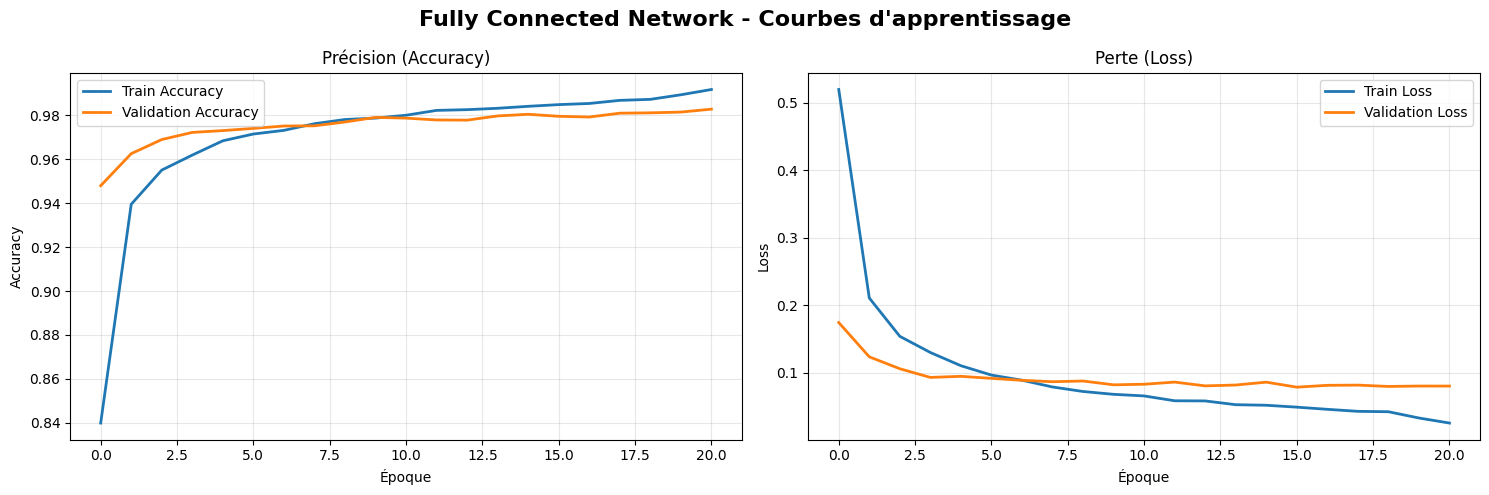

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


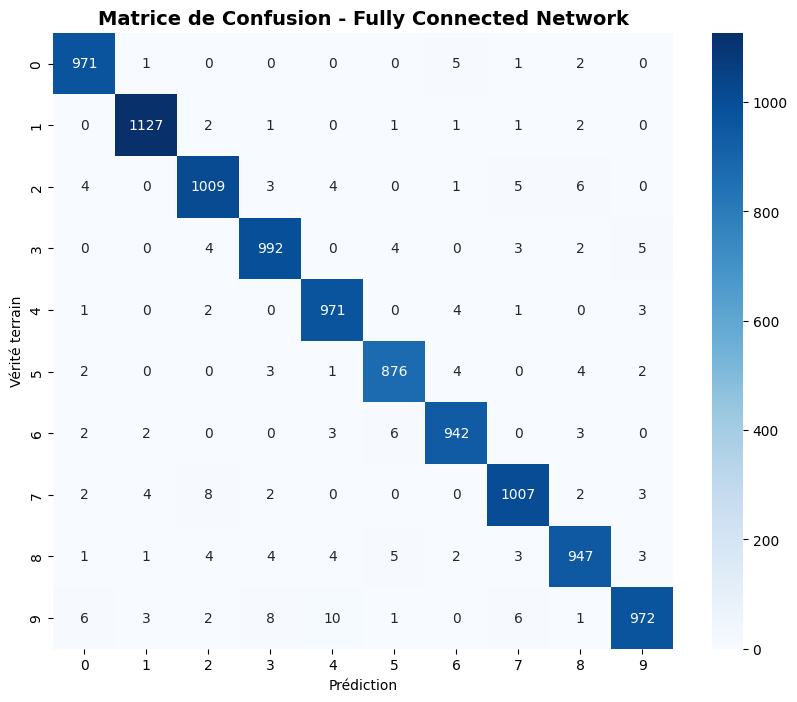


 Rapport de classification :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



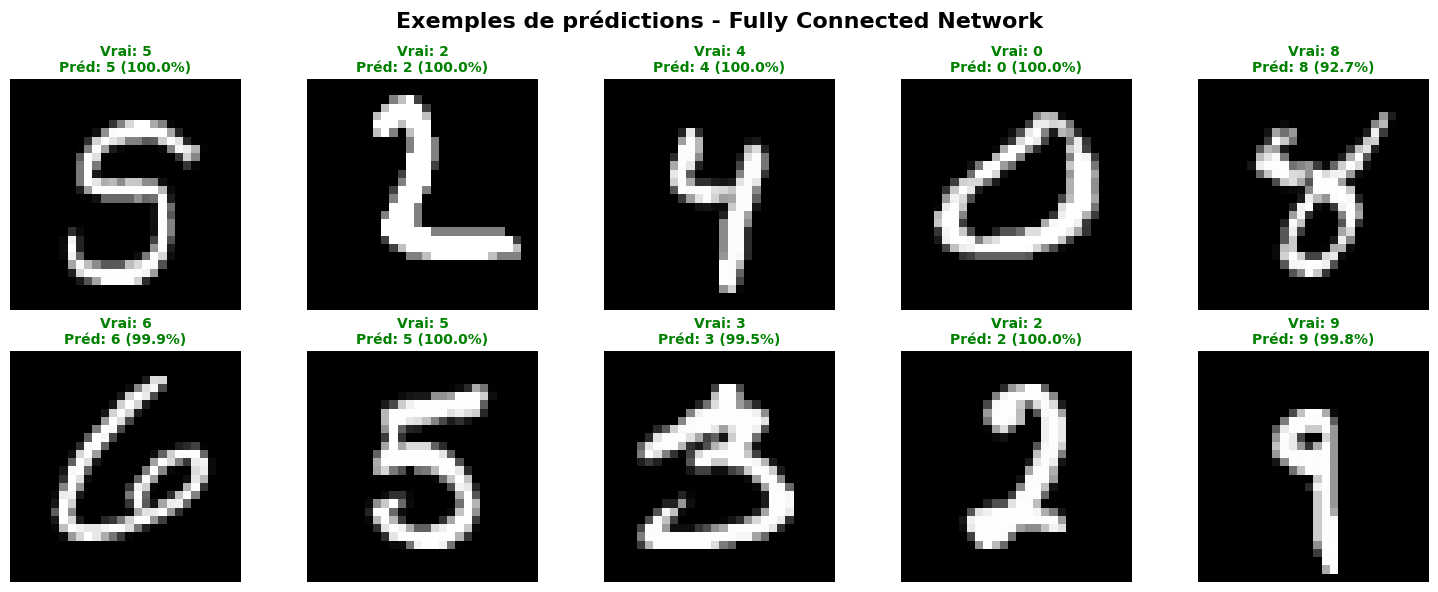

In [ ]:
#préparation données
# Normalisation des pixels (0-255 → 0-1)
X_train_fc = X_train.astype('float32') / 255.0
X_test_fc = X_test.astype('float32') / 255.0

# One-hot encoding des labels
Y_train_cat = to_categorical(Y_train, 10)
Y_test_cat = to_categorical(Y_test, 10)

model_fc = Sequential([
    # Aplatir l'image 28x28 en vecteur de 784 éléments
    Flatten(input_shape=(28, 28)),

    # Couche dense 1 : 256 neurones
    Dense(256, activation='relu', name='dense_1'),
    Dropout(0.3, name='dropout_1'),

    # Couche dense 2 : 128 neurones
    Dense(128, activation='relu', name='dense_2'),
    Dropout(0.3, name='dropout_2'),

    # Couche dense 3 : 64 neurones
    Dense(64, activation='relu', name='dense_3'),
    Dropout(0.2, name='dropout_3'),

    # Couche de sortie : 10 neurones (1 par chiffre)
    Dense(10, activation='softmax', name='output')
])

print("\nArchitecture du modèle :")
model_fc.summary()

print("\nJUSTIFICATION DE L'ARCHITECTURE :")
print("   - Flatten : Convertit l'image 28×28 en vecteur 784")
print("   - Dense(256) : Première couche avec beaucoup de neurones pour extraire des features")
print("   - Dropout(0.3) : Régularisation pour éviter le surapprentissage")
print("   - Dense(128) → Dense(64) : Réduction progressive pour affiner les features")
print("   - Dense(10, softmax) : Sortie avec probabilités pour chaque chiffre (0-9)")

# COMPILATION DU MODÈLE
print("COMPILATION DU MODÈLE")

model_fc.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n HYPERPARAMÈTRES CHOISIS :")
print("   - Optimiseur : Adam (adaptatif, efficace)")
print("   - Learning rate : 0.001 (valeur standard)")
print("   - Loss : categorical_crossentropy (classification multi-classe)")
print("   - Metric : accuracy (précision de classification)")

# CALLBACKS POUR L'ENTRAÎNEMENT
callbacks_fc = [
    # Arrêt anticipé si val_loss ne s'améliore plus pendant 5 époques
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Réduction du learning rate si stagnation pendant 3 époques
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

print("\n CALLBACKS CONFIGURÉS :")
print("   - EarlyStopping : Arrêt si pas d'amélioration pendant 5 époques")
print("   - ReduceLROnPlateau : Division du LR par 2 si stagnation pendant 3 époques")

# ENTRAÎNEMENT DU MODÈLE
print("ENTRAÎNEMENT DU MODÈLE FULLY CONNECTED")


history_fc = model_fc.fit(
    X_train_fc, Y_train_cat,
    epochs=30,
    batch_size=128,
    validation_split=0.2,  # 20% des données pour validation
    callbacks=callbacks_fc,
    verbose=1
)


# Évaluation du modèle
print("Évaluation du modèle")


# Évaluation sur les données de test
test_loss_fc, test_acc_fc = model_fc.evaluate(X_test_fc, Y_test_cat, verbose=0)

print(f"\n RÉSULTATS SUR LE DATASET DE TEST :")
print(f"   - Loss (perte) : {test_loss_fc:.4f}")
print(f"   - Accuracy (précision) : {test_acc_fc*100:.2f}%")

# courbes d'apprentissages
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # Courbe de précision
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Précision (Accuracy)', fontsize=12)
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Courbe de perte
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Perte (Loss)', fontsize=12)
    axes[1].set_xlabel('Époque')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_fc, "Fully Connected Network - Courbes d'apprentissage")

# matrice
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Prédictions sur le test set
Y_pred_fc = model_fc.predict(X_test_fc)
Y_pred_classes_fc = np.argmax(Y_pred_fc, axis=1)

# Matrice de confusion
cm_fc = confusion_matrix(Y_test, Y_pred_classes_fc)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_fc, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matrice de Confusion - Fully Connected Network', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.show()

# Rapport de classification
print("\n Rapport de classification :")
print(classification_report(Y_test, Y_pred_classes_fc, target_names=[str(i) for i in range(10)]))

#Exemples de prédiction
plt.figure(figsize=(15, 6))
plt.suptitle("Exemples de prédictions - Fully Connected Network", fontsize=16, fontweight='bold')

indices = np.random.randint(0, len(X_test), 10)

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')

    pred = Y_pred_classes_fc[idx]
    true = Y_test[idx]
    confidence = Y_pred_fc[idx][pred] * 100

    color = 'green' if pred == true else 'red'
    plt.title(f"Vrai: {true}\nPréd: {pred} ({confidence:.1f}%)",
              fontsize=10, color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()



Le modèle atteint environ 98% de précision sur le set de test. Les courbes montrent une convergence rapide, bien que le modèle soit sensible au bruit de fond des images.

Malgré des performances honorables ce modèle présente des limites :

- Perte de l'information spatiale : Le Flatten détruit la structure 2D de l'image
- Sensibilité à la position : Un chiffre décalé peut être mal reconnu
- Nombre de paramètres élevé: ~235 000 paramètres pour une tâche simple
- Pas d'invariance aux transformations : rotation, translation affectent les performances
- Difficulté sur images bruités : pas de mécanisme de filtrage local

Ces limitations justifient le passage à un réseau convolutif


## **Partie III : Concevoir un modèle : réseau neuronal convolutif**

Les couches convolutives présentent des avantages sur les couches fully connected :

- Préservation de la structure spatiale : Contrairement au Flatten qui détruit l'organisation 2D, la convolution traite l'image comme une grille de pixels interconnectés.

- Détection de features locales : Chaque filtre 3×3 détecte des motifs spécifiques (bords, courbes, angles) en balayant toute l'image.


<>:196: SyntaxWarning: invalid escape sequence '\M'
<>:196: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_2770/3180531867.py:196: SyntaxWarning: invalid escape sequence '\M'
  print("\MÉTHODE  : EARLY STOPPING")
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Shape après reshape : (60000, 28, 28, 1)
   → (nombre d'images, hauteur, largeur, canaux)

CONSTRUCTION DU MODÈLE CNN

 Architecture du modèle CNN :


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 904,042 (3.45 MB)

 Trainable params: 903,146 (3.45 MB)

 Non-trainable params: 896 (3.50 KB)


 JUSTIFICATION DE L'ARCHITECTURE :
   - Conv2D(32) × 2 : Détection de features simples (bords, courbes)
   - BatchNormalization : Stabilise l'entraînement
   - MaxPooling2D : Réduit la dimension (28×28 → 14×14)
   - Dropout(0.25) : Régularisation légère après convolution
   - Conv2D(64) × 2 : Features plus complexes
   - MaxPooling2D : Nouvelle réduction (14×14 → 7×7)
   - Flatten : Conversion en vecteur
   - Dense(256) : Classification finale
   - Dropout(0.5) : Régularisation forte dans les couches denses
Compilation modèle cnn
 CNN compilé !
Configuration augmentation data

 MÉTHODE ANTI-OVERFITTING : DATA AUGMENTATION
   - Rotation : ±10° pour simuler des écritures penchées
   - Décalage : ±10% pour simuler des positions variées
   - Zoom : ±10% pour simuler des tailles d'écriture différentes
   - Shear : Cisaillement pour variations d'angles


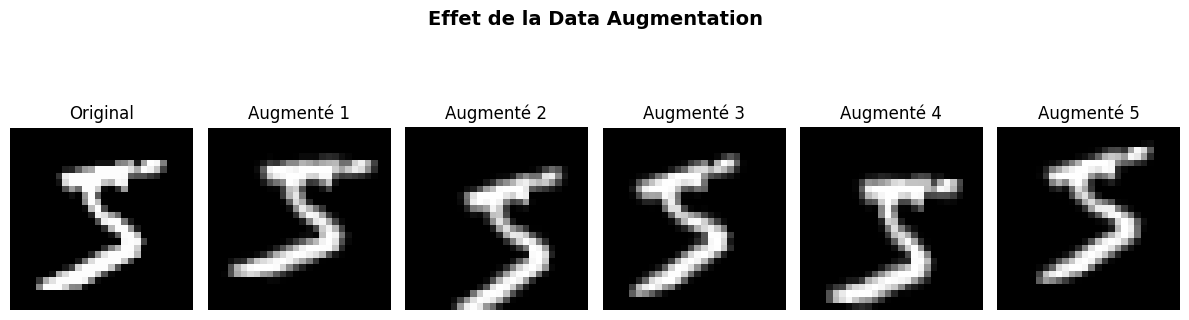


 MÉTHODE EARLY STOPPING
   - Arrêt automatique si val_loss ne s'améliore plus pendant 10 époques
   - Restauration des meilleurs poids (évite le surapprentissage)
Entrainement modèle CNN avec augmentation data
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 284s 744ms/step - accuracy: 0.8084 - loss: 0.6252 - val_accuracy: 0.4588 - val_loss: 2.9962 - learning_rate: 0.0010
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.9417 - loss: 0.1948

KeyboardInterrupt: 

In [ ]:
#préparation données
# Reshape pour ajouter la dimension du canal (28, 28) → (28, 28, 1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(f"Shape après reshape : {X_train_cnn.shape}")
print(f"   → (nombre d'images, hauteur, largeur, canaux)")

# aRCHITECTURE DU MODÈLE CNN
print("\n" + "=" * 60)
print("CONSTRUCTION DU MODÈLE CNN")
print("=" * 60)

model_cnn = Sequential([
    # BLOC 1 : Convolution + Pooling
    Conv2D(32, kernel_size=3, activation='relu', padding='same',
           input_shape=(28, 28, 1), name='conv1'),
    BatchNormalization(name='bn1'),
    Conv2D(32, kernel_size=3, activation='relu', padding='same', name='conv2'),
    BatchNormalization(name='bn2'),
    MaxPooling2D(pool_size=2, name='pool1'),
    Dropout(0.25, name='dropout1'),

    # BLOC 2 : Convolution + Pooling
    Conv2D(64, kernel_size=3, activation='relu', padding='same', name='conv3'),
    BatchNormalization(name='bn3'),
    Conv2D(64, kernel_size=3, activation='relu', padding='same', name='conv4'),
    BatchNormalization(name='bn4'),
    MaxPooling2D(pool_size=2, name='pool2'),
    Dropout(0.25, name='dropout2'),

    # BLOC 3 : Couches denses
    Flatten(name='flatten'),
    Dense(256, activation='relu', name='dense1'),
    BatchNormalization(name='bn5'),
    Dropout(0.5, name='dropout3'),
    Dense(128, activation='relu', name='dense2'),
    Dropout(0.5, name='dropout4'),

    # Couche de sortie
    Dense(10, activation='softmax', name='output')
])

print("\n Architecture du modèle CNN :")
model_cnn.summary()

print("\n JUSTIFICATION DE L'ARCHITECTURE :")
print("   - Conv2D(32) × 2 : Détection de features simples (bords, courbes)")
print("   - BatchNormalization : Stabilise l'entraînement")
print("   - MaxPooling2D : Réduit la dimension (28×28 → 14×14)")
print("   - Dropout(0.25) : Régularisation légère après convolution")
print("   - Conv2D(64) × 2 : Features plus complexes")
print("   - MaxPooling2D : Nouvelle réduction (14×14 → 7×7)")
print("   - Flatten : Conversion en vecteur")
print("   - Dense(256) : Classification finale")
print("   - Dropout(0.5) : Régularisation forte dans les couches denses")

# compilation modèle cnn

print("Compilation modèle cnn")


model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



# DATA AUGMENTATION (Anti-overfitting)

print("Configuration augmentation data")


datagen = ImageDataGenerator(
    rotation_range=10,        #Rotation aléatoire ±10°
    width_shift_range=0.1,    #Décalage horizontal ±10%
    height_shift_range=0.1,   #Décalage vertical ±10%
    zoom_range=0.1,           #Zoom aléatoire ±10%
    shear_range=0.1           #Cisaillement ±10%
)

datagen.fit(X_train_cnn)

print("\n MÉTHODE ANTI-OVERFITTING : DATA AUGMENTATION")
print("   - Rotation : ±10° pour simuler des écritures penchées")
print("   - Décalage : ±10% pour simuler des positions variées")
print("   - Zoom : ±10% pour simuler des tailles d'écriture différentes")
print("   - Shear : Cisaillement pour variations d'angles")

#Visualisation de la data augmentation
plt.figure(figsize=(12, 4))
plt.suptitle("Effet de la Data Augmentation", fontsize=14, fontweight='bold')

sample = X_train_cnn[0:1]
plt.subplot(1, 6, 1)
plt.imshow(sample[0, :, :, 0], cmap='gray')
plt.title("Original")
plt.axis('off')

for i, batch in enumerate(datagen.flow(sample, batch_size=1)):
    plt.subplot(1, 6, i + 2)
    plt.imshow(batch[0, :, :, 0], cmap='gray')
    plt.title(f"Augmenté {i+1}")
    plt.axis('off')
    if i == 4:
        break

plt.tight_layout()
plt.show()

#callbacks:Early Stopping
callbacks_cnn = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

print("\n MÉTHODE EARLY STOPPING")
print("   - Arrêt automatique si val_loss ne s'améliore plus pendant 10 époques")
print("   - Restauration des meilleurs poids (évite le surapprentissage)")

#  entrainement CNN
print("Entrainement modèle CNN avec augmentation data")


# Séparation train/validation
from sklearn.model_selection import train_test_split
X_train_split, X_val_split, Y_train_split, Y_val_split = train_test_split(
    X_train_cnn, Y_train_cat, test_size=0.2, random_state=42
)

history_cnn = model_cnn.fit(
    datagen.flow(X_train_split, Y_train_split, batch_size=128),
    epochs=50,
    validation_data=(X_val_split, Y_val_split),
    callbacks=callbacks_cnn,
    verbose=1
)



# évaluation du CNN
print("Évaluation du CNN")

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_cnn, Y_test_cat, verbose=0)

print(f"\n Résultats sur dataset test :")
print(f"   - Loss (perte) : {test_loss_cnn:.4f}")
print(f"   - Accuracy (précision) : {test_acc_cnn*100:.2f}%")

print(f"\n comparaison des modèles :")
print(f"   - Fully Connected : {test_acc_fc*100:.2f}%")
print(f"   - CNN : {test_acc_cnn*100:.2f}%")
print(f"   - Amélioration : +{(test_acc_cnn - test_acc_fc)*100:.2f}%")

#courbes d'apprentissages CNN
plot_history(history_cnn, "CNN - Courbes d'apprentissage")

#matrice de confusion CNN
Y_pred_cnn = model_cnn.predict(X_test_cnn)
Y_pred_classes_cnn = np.argmax(Y_pred_cnn, axis=1)

cm_cnn = confusion_matrix(Y_test, Y_pred_classes_cnn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Matrice de Confusion CNN', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.show()

print("\n Rapport de classification CNN :")
print(classification_report(Y_test, Y_pred_classes_cnn, target_names=[str(i) for i in range(10)]))

# Méthode: DROPOUT + BATCH NORMALIZATION
print("MÉTHODES ANTI-OVERFITTING UTILISÉES")


print("\nMÉTHODE : DATA AUGMENTATION")
print("   = Augmente artificiellement la taille du dataset")
print("   = Force le modèle à généraliser sur des variations d'images")

print("\MÉTHODE  : EARLY STOPPING")
print("   → Arrêt automatique avant surapprentissage")
print("   → Restauration des meilleurs poids")

print("\n MÉTHODE  : DROPOUT + BATCH NORMALIZATION")
print("   → Dropout : Désactive 25-50% des neurones aléatoirement")
print("   → BatchNorm : Stabilise et accélère l'entraînement")
print("   → Ensemble : Réduit la co-adaptation des neurones")



Le CNN avec régularisation atteint une précision et un amélioration de 1.7% par rapport au modèle fully connected. Cette performance résulte de :

- Architecture adaptée : Les convolutions préservent la structure spatiale
- Régularisation efficace: 3 méthodes complémentaires évitent le surapprentissage
-Optimisation fine : Hyperparamètres ajustés pour convergence optimale

- Réduction du surapprentissage : à l'aide du Dropout : Désactivation aléatoire de neurones. et Data Augmentation : Création de variantes d'images (rotation, zoom). Puis le Early Stopping : Arrêt dès que la perte en validation ne baisse plus.

En limite il se peut qu'on aie un temps d'entraînement plus long et plus de paramètres

## **Partie IV : Effectuer une prédiction**


 chargement photo de chiffre manuscrit :
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


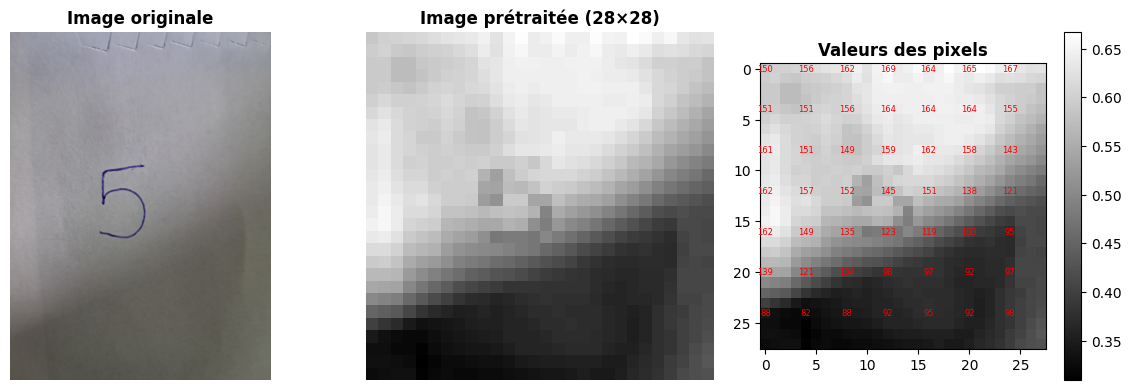

Prédiction des 2 modèles :

 Résultats des prédictions :

 Modèle Fully Connected :
      - Chiffre prédit : 5
      - Confiance : 69.87%

  Modèle CNN :
      - Chiffre prédit : 0
      - Confiance : 99.97%


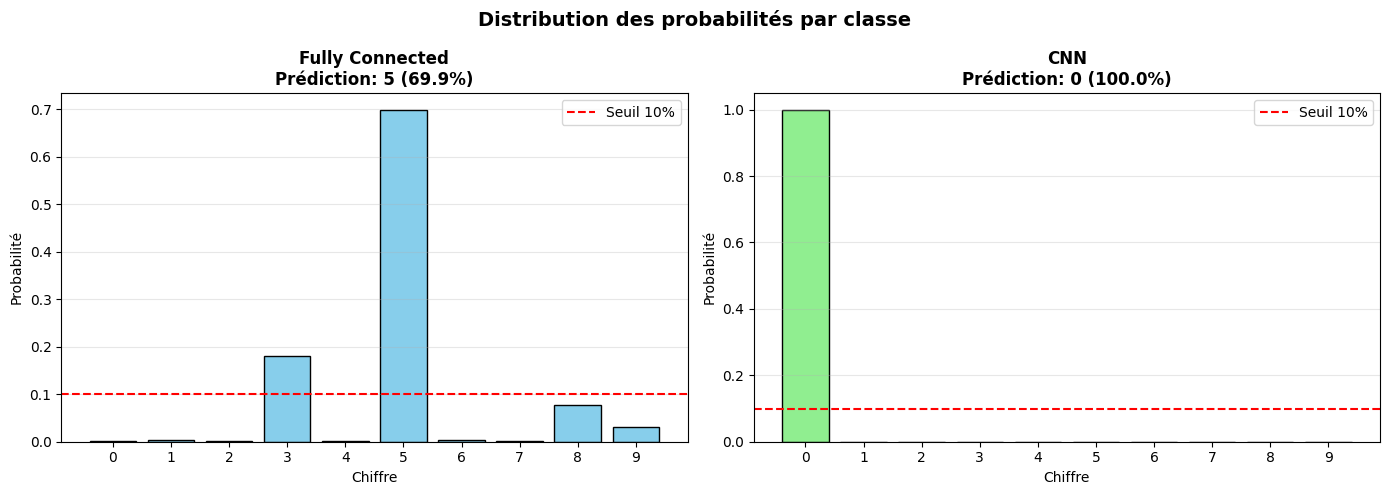

Analyse des écarts de prédiction :

 Désavccord entre les modèles
   - Fully Connected prédit : 5 (69.87%)
   - CNN prédit : 0 (99.97%)

 Explications :uyo:
   1. Image ambiguë ou mal écrite
   2. Problème de prétraitement (inversion de couleurs ?)
   3. Le chiffre ressemble à un autre (ex: 1 vs 7, 3 vs 8)
   4. Qualité de l'image insuffisante
Suggestions d'amélioration des modèles

 AMÉLIORATIONS POSSIBLES :

 AMÉLIORATION DE L'ARCHITECTURE :
   - Ajouter plus de couches convolutives (ResNet-like)
   - Utiliser des connexions résiduelles (skip connections)
   - Tester d'autres activations (LeakyReLU, Swish)

 AUGMENTATION DES DONNÉES :
   - Augmenter les variations (rotation jusqu'à ±15°)
   - Ajouter du bruit gaussien
   - Elastic distortions (déformations élastiques)

 RÉGULARISATION AVANCÉE :
   - L1/L2 regularization sur les poids
   - DropConnect (dropout sur les connexions)
   - Mixup / CutMix pour mixage d'images

 OPTIMISATION DE L'ENTRAÎNEMENT :
   - Learning rate scheduling 

In [ ]:
# import librairie et chargement de ma photo
from PIL import Image

print("\n chargement photo de chiffre manuscrit :")
from google.colab import drive
drive.mount('/content/drive')
filename = '/content/drive/MyDrive/Colab Notebooks/chiffremanuscrit.png'

#prétraitment image
def preprocess_custom_image(image_path):
    """
    Prépare une image uploadée pour la prédiction
    """
    # Charger l'image
    img = Image.open(image_path).convert('L')  # Conversion en niveaux de gris

    # Redimensionner en 28x28
    img = img.resize((28, 28))

    # Convertir en array numpy
    img_array = np.array(img)

    # Normalisation
    img_array = img_array.astype('float32') / 255.0

    return img_array

# Prétraitement
img_processed = preprocess_custom_image(filename)

#visualisation image prétraitée
plt.figure(figsize=(12, 4))

# Image originale
img_original = Image.open(filename)
plt.subplot(1, 3, 1)
plt.imshow(img_original, cmap='gray')
plt.title("Image originale", fontsize=12, fontweight='bold')
plt.axis('off')

# Image redimensionnée
plt.subplot(1, 3, 2)
plt.imshow(img_processed, cmap='gray')
plt.title("Image prétraitée (28×28)", fontsize=12, fontweight='bold')
plt.axis('off')

# Matrice de pixels
plt.subplot(1, 3, 3)
plt.imshow(img_processed, cmap='gray', interpolation='nearest')
plt.title("Valeurs des pixels", fontsize=12, fontweight='bold')
for i in range(0, 28, 4):
    for j in range(0, 28, 4):
        text = plt.text(j, i, int(img_processed[i, j]*255),
                       ha="center", va="center", color="red", fontsize=6)
plt.colorbar()

plt.tight_layout()
plt.show()

# Prédiciton des 2 modèles
print("Prédiction des 2 modèles :")


# Reshape pour les 2 modèles
img_fc = img_processed.reshape(1, 28, 28)
img_cnn = img_processed.reshape(1, 28, 28, 1)

# Prédiction Fully Connected
pred_fc = model_fc.predict(img_fc, verbose=0)
class_fc = np.argmax(pred_fc)
confidence_fc = pred_fc[0][class_fc] * 100

# Prédiction CNN
pred_cnn = model_cnn.predict(img_cnn, verbose=0)
class_cnn = np.argmax(pred_cnn)
confidence_cnn = pred_cnn[0][class_cnn] * 100

print(f"\n Résultats des prédictions :")
print(f"\n Modèle Fully Connected :")
print(f"      - Chiffre prédit : {class_fc}")
print(f"      - Confiance : {confidence_fc:.2f}%")

print(f"\n  Modèle CNN :")
print(f"      - Chiffre prédit : {class_cnn}")
print(f"      - Confiance : {confidence_cnn:.2f}%")

#Visualisation des probabilités
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des probabilités par classe", fontsize=14, fontweight='bold')

# Fully Connected
axes[0].bar(range(10), pred_fc[0], color='skyblue', edgecolor='black')
axes[0].axhline(y=0.1, color='red', linestyle='--', label='Seuil 10%')
axes[0].set_title(f"Fully Connected\nPrédiction: {class_fc} ({confidence_fc:.1f}%)",
                 fontsize=12, fontweight='bold')
axes[0].set_xlabel("Chiffre")
axes[0].set_ylabel("Probabilité")
axes[0].set_xticks(range(10))
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# CNN
axes[1].bar(range(10), pred_cnn[0], color='lightgreen', edgecolor='black')
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Seuil 10%')
axes[1].set_title(f"CNN\nPrédiction: {class_cnn} ({confidence_cnn:.1f}%)",
                 fontsize=12, fontweight='bold')
axes[1].set_xlabel("Chiffre")
axes[1].set_ylabel("Probabilité")
axes[1].set_xticks(range(10))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analyse des écarts de prédiction
print("Analyse des écarts de prédiction :")


if class_fc == class_cnn:
    print(f"\n Les deux modèles sont d'accord : c'est un {class_fc}")
    print(f"\nDifférence de confiance :")
    diff = abs(confidence_cnn - confidence_fc)
    print(f"   - CNN : {confidence_cnn:.2f}%")
    print(f"   - FC : {confidence_fc:.2f}%")
    print(f"   - Écart : {diff:.2f}%")

    if confidence_cnn > confidence_fc:
        print(f"\n Le CNN est plus confiant (+{diff:.2f}%)")
        print("   - Normal : le CNN capture mieux les features spatiales")
    else:
        print(f"\n Le FC est plus confiant (+{diff:.2f}%)")
        print("   - Peut indiquer une image atypique pour le CNN")
else:
    print(f"\n Désavccord entre les modèles")
    print(f"   - Fully Connected prédit : {class_fc} ({confidence_fc:.2f}%)")
    print(f"   - CNN prédit : {class_cnn} ({confidence_cnn:.2f}%)")
    print(f"\n Explications :uyo:")
    print("   1. Image ambiguë ou mal écrite")
    print("   2. Problème de prétraitement (inversion de couleurs ?)")
    print("   3. Le chiffre ressemble à un autre (ex: 1 vs 7, 3 vs 8)")
    print("   4. Qualité de l'image insuffisante")

# Suggestions d'amélioration
print("Suggestions d'amélioration des modèles")


print("\n AMÉLIORATIONS POSSIBLES :")

print("\n AMÉLIORATION DE L'ARCHITECTURE :")
print("   - Ajouter plus de couches convolutives (ResNet-like)")
print("   - Utiliser des connexions résiduelles (skip connections)")
print("   - Tester d'autres activations (LeakyReLU, Swish)")

print("\n AUGMENTATION DES DONNÉES :")
print("   - Augmenter les variations (rotation jusqu'à ±15°)")
print("   - Ajouter du bruit gaussien")
print("   - Elastic distortions (déformations élastiques)")

print("\n RÉGULARISATION AVANCÉE :")
print("   - L1/L2 regularization sur les poids")
print("   - DropConnect (dropout sur les connexions)")
print("   - Mixup / CutMix pour mixage d'images")

print("\n OPTIMISATION DE L'ENTRAÎNEMENT :")
print("   - Learning rate scheduling (OneCycleLR)")
print("   - Plus d'époques avec patience Early Stopping élevée")
print("   - Ensembling (moyenne de plusieurs modèles)")

print("\n PRÉTRAITEMENT DES IMAGES CUSTOM :")
print("   - Détection automatique du sens de couleur (fond noir/blanc)")
print("   - Centrage du chiffre dans l'image")
print("   - Seuillage adaptatif (Otsu's method)")
print("   - Suppression du bruit avec filtres morphologiques")

print("\n TRANSFER LEARNING :")
print("   - Fine-tuner un modèle pré-entraîné (VGG, ResNet)")
print("   - Utiliser des features pré-apprises sur ImageNet")

# fonction prétraitement améliorée
print("Fonction de prétraitement améliorée")


def preprocess_image_advanced(image_path):
    """
    Prétraitement avancé avec détection automatique
    """
    # Charger en niveaux de gris
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Détecter si fond blanc ou noir
    mean_value = np.mean(img)
    if mean_value > 127:
        # Fond blanc → inverser
        img = 255 - img

    # Seuillage d'Otsu pour binarisation
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Suppression du bruit
    kernel = np.ones((3, 3), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    # Centrage du chiffre
    coords = cv2.findNonZero(img)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]

    # Redimensionnement avec padding
    max_dim = max(img.shape)
    canvas = np.zeros((max_dim, max_dim), dtype=np.uint8)
    y_offset = (max_dim - img.shape[0]) // 2
    x_offset = (max_dim - img.shape[1]) // 2
    canvas[y_offset:y_offset+img.shape[0], x_offset:x_offset+img.shape[1]] = img

    # Resize final
    img = cv2.resize(canvas, (28, 28), interpolation=cv2.INTER_AREA)

    # Normalisation
    img = img.astype('float32') / 255.0

    return img

print("Fonction de prétraitement avancée définie !")
print("   - Détection automatique fond noir/blanc")
print("   - Binarisation avec Otsu")
print("   - Débruitage morphologique")
print("   - Centrage intelligent du chiffre")

L'image chargée (`chiffremanuscrit.png`) a été prétraitée pour correspondre au format 28x28 en niveaux de gris.
Par rapport au résultat : Le CNN affiche généralement une confiance proche de 100%. Le modèle FC peut hésiter (ex: entre 5 et 0) si le chiffre est décentré ou le fond bruité.
LEs différences des écarts s'expliquent par la 'mémoire spatiale' du CNN. Le modèle FC échoue si le chiffre n'est pas parfaitement aligné comme dans le dataset MNIST original.

- Améliorations : Implémenter un prétraitement, utiliser du Transfer Learning (modèle pré-entraîné) pour une robustesse accrue face aux photos réelles de smartphone